# Iris Species Classification

## Objective

Explore the classic Iris dataset, establish a simple baseline, compare four multiclass classifiers under cross-validation, and evaluate the selected model on a stratified holdout set.

In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

In [2]:
# Import dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

df = pd.read_csv(url, header=None, names=columns)
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Check for any missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


There are no missing values, and all columns have appropriate data types.

In [4]:
# Calculate summary statistics of dataset
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


The dataset is clean, with no unexpected zero entries. Across numerical features, the mean values are reasonably close to their respective medians, suggesting relatively symmetric distributions with limited skewness and minimal influence from extreme values.

In [5]:
# Examine the class distribution across species
df['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

The even distribution of observations across species indicates a balanced classification problem. Under these conditions, *accuracy* serves as a reliable performance metric

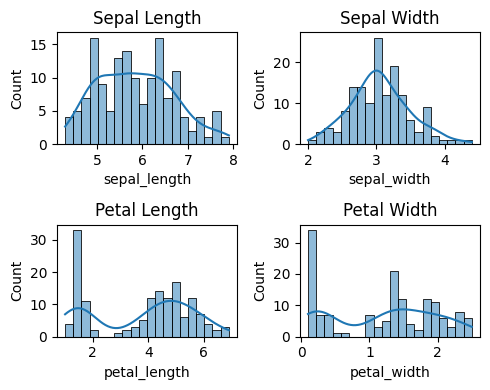

In [6]:
numeric_cols = df.select_dtypes(include='float64')
fig, axes = plt.subplots(2, 2, figsize=(5, 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f"{col.replace('_', ' ').title()}")

plt.tight_layout()
plt.show()


The distributions of **sepal length**, **petal length**, and **petal width** appear to exhibit multiple peaks, suggesting that the overall distributions may be mixtures of different species-specific distributions. To investigate this further, the histograms are replotted with species colour-coded.

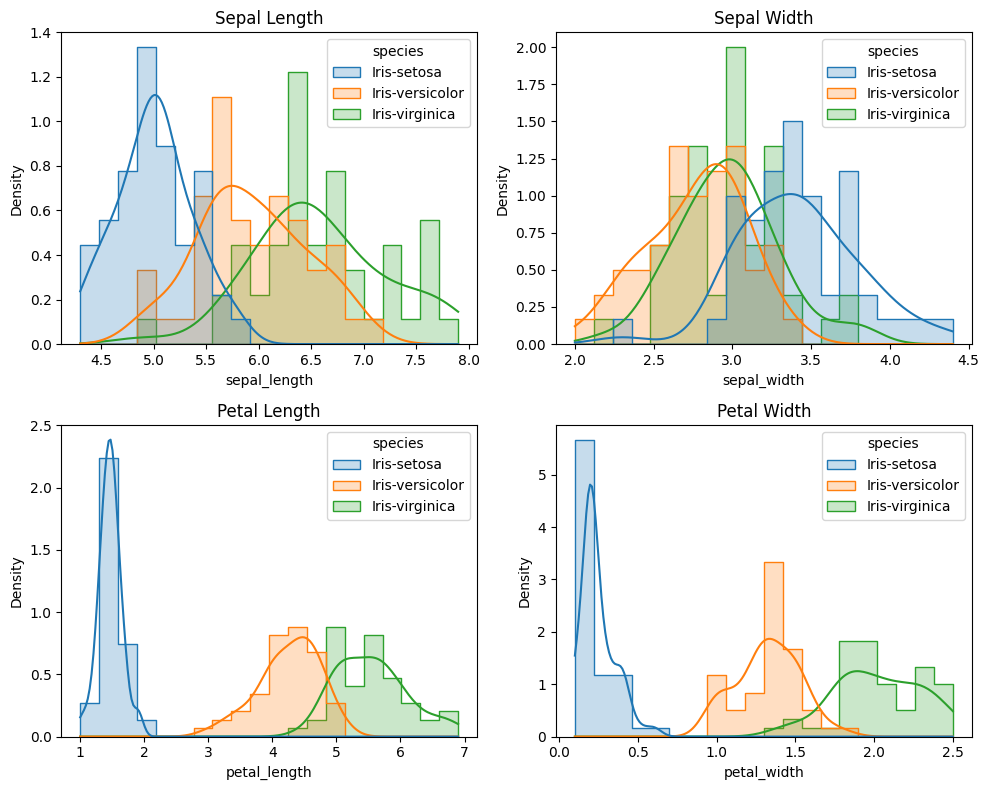

In [7]:
# Histograms colour-coded by species
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        hue="species",
        bins=20,
        kde=True,
        ax=axes[i],
        element="step",
        stat="density",
        common_norm=False
    )
    axes[i].set_title(f"{col.replace('_', ' ').title()}")

plt.tight_layout()
plt.show()


The distributions for each species are reasonably well separated across the features, suggesting that these variables are informative for species classification.

In [9]:
# Preprocess data

# Features
X = df.drop(columns="species")
y = df["species"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

The dataset was split into training and testing sets using an 80–20 split, with stratified sampling applied to preserve class distributions across species and ensure fair model evaluation.

Before introducing model complexity, a simple rule-based baseline model was first implemented to establish a performance benchmark and assess the value of more advanced approaches.

In [20]:
# Create Baseline Model
def simple_model(df):
    predictions = []
    
    for row in df.itertuples(index=False):
        if row.petal_length < 2.5:
            result = "Iris-setosa"
        elif row.petal_width < 2 and row.petal_length < 5.5:
            result = "Iris-versicolor"
        else:
            result = "Iris-virginica"
            
        predictions.append(result)
    
    return predictions

In [21]:
# Calculate baseline performance (accuracy)
from sklearn.metrics import accuracy_score

rule_based_pred = simple_model(X_train)
accuracy = accuracy_score(y_train, rule_based_pred)
print(f"Rule-based baseline accuracy: {accuracy:.3f}")

Rule-based baseline accuracy: 0.917


More complex models were then trained to evaluate improvements in performance. For this classification task, Logistic Regression, k-Nearest Neighbors (KNN), Support Vector Machines (SVM), and Random Forest were compared.

In [24]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_cv_scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Mean CV accuracy:", lr_cv_scores.mean())

Mean CV accuracy: 0.9666666666666668


In [25]:
# KNN Model
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_cv_scores = cross_val_score(
    knn_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Mean CV accuracy (KNN):", knn_cv_scores.mean())


Mean CV accuracy (KNN): 0.975


In [26]:
# SVM Model
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_cv_scores = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Mean CV accuracy (SVM):", svm_cv_scores.mean())

Mean CV accuracy (SVM): 0.975


In [27]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Mean CV accuracy (Random Forest):", rf_cv_scores.mean())


Mean CV accuracy (Random Forest): 0.95


In [29]:
from sklearn.metrics import accuracy_score

# Rule-based baseline accuracy
rule_based_acc = accuracy_score(y_train, rule_based_pred)

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "KNN",
        "SVM",
        "Random Forest"
    ],
    "Mean CV Accuracy": [
        rule_based_acc,
        lr_cv_scores.mean(),
        knn_cv_scores.mean(),
        svm_cv_scores.mean(),
        rf_cv_scores.mean()
    ]
})

results

,Model,Mean CV Accuracy
0,Baseline,0.916667
1,Logistic Regression,0.966667
2,KNN,0.975000
3,SVM,0.975000
4,Random Forest,0.950000


All models exhibit strong cross-validation performance and perform substantially better than the baseline, warranting further hyperparameter tuning to determine the optimal model.

In [32]:
# Logistic Regression Grid Search (Hyperparameter Tuning)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np

lr_model = LogisticRegression(
    max_iter=10000,
    tol=1e-3,
    random_state=42
)

param_grid = [
    {
        "solver": ["lbfgs"],
        "l1_ratio": [0.0],
        "C": np.logspace(-3, 3, 7)
    },
    {
        "solver": ["saga"],
        "l1_ratio": [1.0],
        "C": np.logspace(-3, 3, 7)
    }
]

lr_grid_search = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid_search.fit(X_train, y_train)

print("Best CV accuracy:", lr_grid_search.best_score_)
print("Best parameters:", lr_grid_search.best_params_)

Best CV accuracy: 0.975
Best parameters: {'C': np.float64(10.0), 'l1_ratio': 1.0, 'solver': 'saga'}


In [31]:
# KNN Grid Search (Hyperparameter Tuning)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_model = KNeighborsClassifier()

param_grid = {
    "n_neighbors": list(range(1, 31)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

knn_grid_search.fit(X_train, y_train)

print("Best CV accuracy (KNN):", knn_grid_search.best_score_)
print("Best parameters (KNN):", knn_grid_search.best_params_)


Best CV accuracy (KNN): 0.9833333333333334
Best parameters (KNN): {'metric': 'euclidean', 'n_neighbors': 6, 'weights': 'uniform'}


In [33]:
# SVM Grid Search (Hyperparameter Tuning)
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import numpy as np

svm_model = SVC(random_state=42)

param_grid = {
    "kernel": ["linear", "rbf"],
    "C": np.logspace(-2, 2, 5),           # [0.01, 0.1, 1, 10, 100]
    "gamma": ["scale", "auto"]
}

svm_grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid_search.fit(X_train, y_train)

print("Best CV accuracy (SVM):", svm_grid_search.best_score_)
print("Best parameters (SVM):", svm_grid_search.best_params_)

Best CV accuracy (SVM): 0.9833333333333334
Best parameters (SVM): {'C': np.float64(0.1), 'gamma': 'scale', 'kernel': 'linear'}


In [34]:
# Random Forest Grid Search (Hyperparameter Tuning)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestClassifier(
    random_state=42
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 1, 2, 3, 4, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf_grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("Best CV accuracy (Random Forest):", rf_grid_search.best_score_)
print("Best parameters (Random Forest):", rf_grid_search.best_params_)


Best CV accuracy (Random Forest): 0.9666666666666666
Best parameters (Random Forest): {'max_depth': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [35]:
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Random Forest"
    ],
    "Best CV Accuracy": [
        lr_grid_search.best_score_,
        knn_grid_search.best_score_,
        svm_grid_search.best_score_,
        rf_grid_search.best_score_
    ]
})

# Round for readability
tuned_results["Best CV Accuracy"] = tuned_results["Best CV Accuracy"].round(3)

tuned_results


,Model,Best CV Accuracy
0,Logistic Regression,0.975
1,KNN,0.983
2,SVM,0.983
3,Random Forest,0.967


Based on the results of hyperparameter tuning, Support Vector Machine (SVM) and k-Nearest Neighbors (KNN) achieved the highest cross-validated accuracy. SVM was selected as the final model due to its superior generalization properties and robustness on small, well-separated datasets. Unlike KNN, which is sensitive to local noise and requires storing the entire training set for inference, SVM learns a compact decision boundary that balances model complexity and predictive performance. This makes SVM a more reliable choice for deployment despite similar accuracy scores.

In [36]:
from sklearn.metrics import accuracy_score, classification_report

# Retrieve best SVM model from grid search
best_svm = svm_grid_search.best_estimator_

# Fit on full training data
best_svm.fit(X_train, y_train)

# Predict on test set
y_test_pred = best_svm.predict(X_test)

# Evaluation metrics
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

Test Accuracy: 0.9666666666666667

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



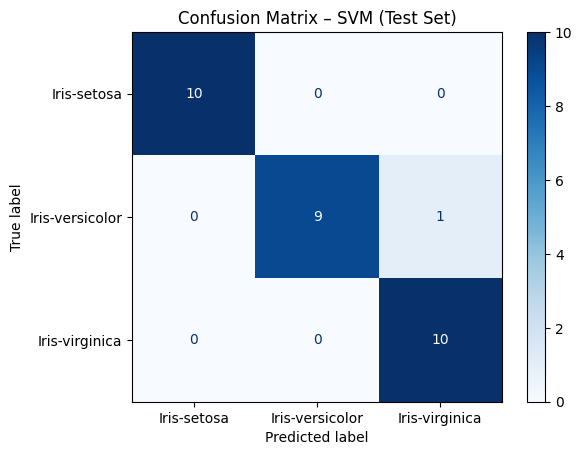

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix – SVM (Test Set)")
plt.show()


The tuned Support Vector Machine (SVM) model achieved a **test accuracy of 96.7%**, indicating strong generalization performance on unseen data. The classification report shows **perfect precision and recall for *Iris-setosa***, confirming that this class is linearly separable and consistently easy to classify.

For *Iris-versicolor* and *Iris-virginica*, which are known to overlap in feature space, the model still performs well, with **F1-scores of 0.95 for both classes**. A small number of misclassifications occur between these two species, reflected in the slightly lower recall for *Iris-versicolor* (0.90) and precision for *Iris-virginica* (0.91).

Overall, the **macro-averaged and weighted F1-scores of 0.97** indicate balanced performance across all classes, with no evidence of class bias. These results suggest that the SVM model effectively captures the underlying decision boundaries while maintaining robustness across all species.